# Análisis de Satisfacción del Cliente — Reseñas de Restaurantes
**Autor:** Rodolfo Gabriel Riveros Lobos | **Fecha:** 23/04/2026  
**Objetivo:** Identificar patrones en reseñas negativas para proponer acciones de mejora continua.

📦 Dataset
Zomato Restaurant Reviews (Kaggle)
🔗 https://www.kaggle.com/datasets/d4rklucif3r/restaurant-reviews

### Configuración de Kaggle API

Primero, instalaremos la biblioteca de Kaggle y crearemos el directorio necesario para tus credenciales.

In [4]:
pip install kaggle

In [5]:
# Crea el directorio .kaggle si no existe
!mkdir -p ~/.kaggle/

# Mueve el archivo kaggle.json subido al directorio correcto
# Asegúrate de que el archivo 'kaggle.json' esté en la raíz de tu sesión de Colab antes de ejecutar esto
!mv kaggle.json ~/.kaggle/

# Establece permisos para el archivo kaggle.json (solo lectura para el propietario)
!chmod 600 ~/.kaggle/kaggle.json

print("Configuración de kaggle.json completada. Ahora puedes intentar descargar el dataset nuevamente.")

mv: cannot stat 'kaggle.json': No such file or directory
Configuración de kaggle.json completada. Ahora puedes intentar descargar el dataset nuevamente.


### Descarga y carga del dataset

Ahora que Kaggle API está configurado, podemos descargar el dataset y cargarlo en un DataFrame de pandas.

In [6]:
import kaggle
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys # Importar sys para manejar errores internos de la librería kaggle

# El nombre del dataset en Kaggle es 'd4rklucif3r/restaurant-reviews'
dataset_name = 'd4rklucif3r/restaurant-reviews'

try:
    # Descarga el dataset
    kaggle.api.dataset_download_files(dataset_name, path='./', unzip=False)

    # Descomprime el archivo (el nombre del archivo zip suele ser el último componente del dataset_name)
    zip_file_name = dataset_name.split('/')[-1] + '.zip'
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('./')

    print(f"Archivos descomprimidos de {zip_file_name}:")
    print(os.listdir('./'))
except Exception as e:
    print(f"Error al descargar o descomprimir el dataset: {e}")
    print("Por favor, asegúrate de que tu archivo 'kaggle.json' está subido y configurado correctamente, y que tienes permisos para el dataset.")


Dataset URL: https://www.kaggle.com/datasets/d4rklucif3r/restaurant-reviews
Archivos descomprimidos de restaurant-reviews.zip:
['.config', 'Restaurant_Reviews.tsv', '.ipynb_checkpoints', 'restaurant-reviews.zip', 'kaggle', 'sample_data']


### Configuración Manual del `kaggle.json`

Si encontraste un error de autenticación con la API de Kaggle, es probable que necesites configurar manualmente tu archivo `kaggle.json`. Sigue las instrucciones a continuación para asegurarte de que tus credenciales estén en el lugar correcto y con los permisos adecuados.

In [7]:
#Carga y lectura del dataset

df = pd.read_csv('Restaurant_Reviews.tsv', sep='\t')
print(df.shape)
df.head()

(1000, 2)


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


### Contenido y Estructura del Dataset

Este dataset (`df`) contiene una colección de reseñas de restaurantes, con el objetivo de clasificar si la reseña es positiva o negativa. Consta de las siguientes columnas:

*   **Review**: El texto de la reseña del restaurante.
*   **Liked**: Una variable binaria (0 o 1) que indica si la reseña fue positiva (1) o negativa (0).

El dataset tiene **1000 filas** y **2 columnas**, proporcionando un conjunto de datos adecuado para tareas de procesamiento de lenguaje natural y clasificación de sentimientos.

In [8]:
# --- LIMPIEZA BÁSICA ---
print("=== NULOS POR COLUMNA ===")
print(df.isnull().sum())

print(f"\n=== DUPLICADOS: {df.duplicated().sum()} filas duplicadas ===")

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print(f"\n=== SHAPE: {df.shape[0]} filas | {df.shape[1]} columnas ===")

=== NULOS POR COLUMNA ===
Review    0
Liked     0
dtype: int64

=== DUPLICADOS: 4 filas duplicadas ===

=== TIPOS DE DATOS ===
Review    object
Liked      int64
dtype: object

=== SHAPE: 1000 filas | 2 columnas ===


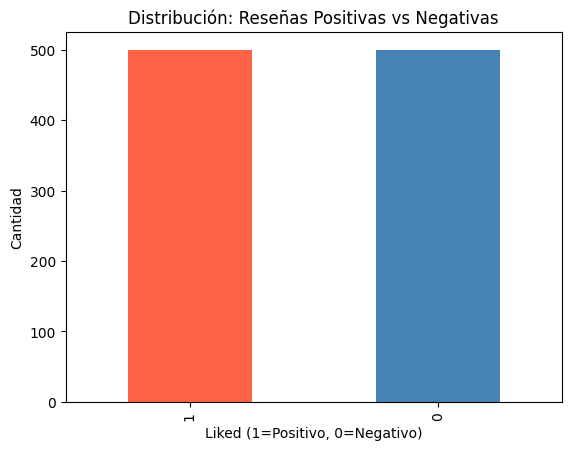

In [9]:
#Análisis de distribución de ratings

df['Liked'].value_counts().plot(kind='bar', color=['tomato','steelblue'])
plt.title('Distribución: Reseñas Positivas vs Negativas')
plt.xlabel('Liked (1=Positivo, 0=Negativo)')
plt.ylabel('Cantidad')
plt.show()

Ambas barras, la de "0" (reseñas negativas) y la de "1" (reseñas positivas), tienen alturas muy similares, lo que indica que hay una cantidad casi igual de cada tipo de reseña en el dataset. Esto es favorable para la clasificación de sentimientos, ya que un dataset balanceado ayuda a entrenar modelos más justos.

In [10]:
# --- ANÁLISIS DE TEXTO BÁSICO ---
from collections import Counter
import re

# Filtros de segmentación
negativas = df[df['Liked'] == 0]
positivas = df[df['Liked'] == 1]

# Stopwords básicas en inglés
STOPWORDS = {
    'this', 'that', 'with', 'have', 'from', 'they', 'will',
    'been', 'were', 'their', 'what', 'your', 'just', 'like',
    'very', 'also', 'more', 'than', 'when', 'there', 'here'
}

def top_words(df_filtrado, n=15):
    texto = ' '.join(df_filtrado['Review'].str.lower())
    palabras = re.findall(r'\b[a-z]{4,}\b', texto)
    palabras_filtradas = [p for p in palabras if p not in STOPWORDS]
    return Counter(palabras_filtradas).most_common(n)

print("TOP palabras NEGATIVAS:", top_words(negativas))
print("TOP palabras POSITIVAS:", top_words(positivas))

TOP palabras NEGATIVAS: [('food', 66), ('place', 49), ('back', 38), ('service', 38), ('good', 22), ('would', 22), ('never', 22), ('time', 20), ('ever', 19), ('minutes', 19), ('only', 16), ('again', 16), ('much', 15), ('worst', 14), ('really', 14)]
TOP palabras POSITIVAS: [('good', 73), ('great', 70), ('food', 60), ('place', 57), ('service', 47), ('friendly', 24), ('delicious', 23), ('back', 23), ('amazing', 22), ('nice', 22), ('time', 22), ('really', 22), ('best', 22), ('restaurant', 17), ('love', 16)]


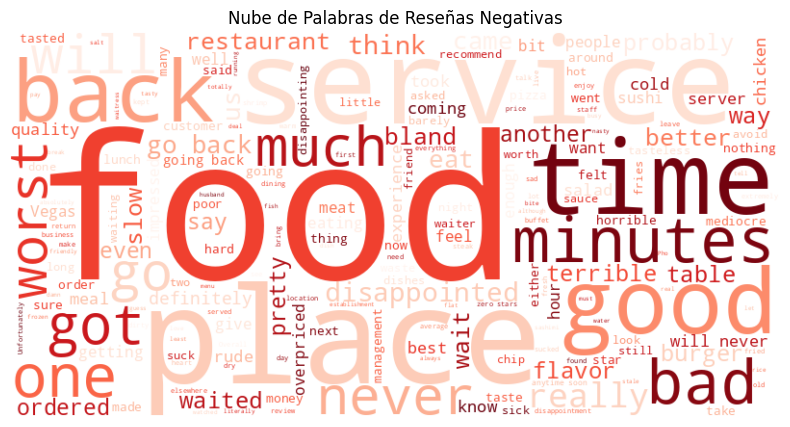

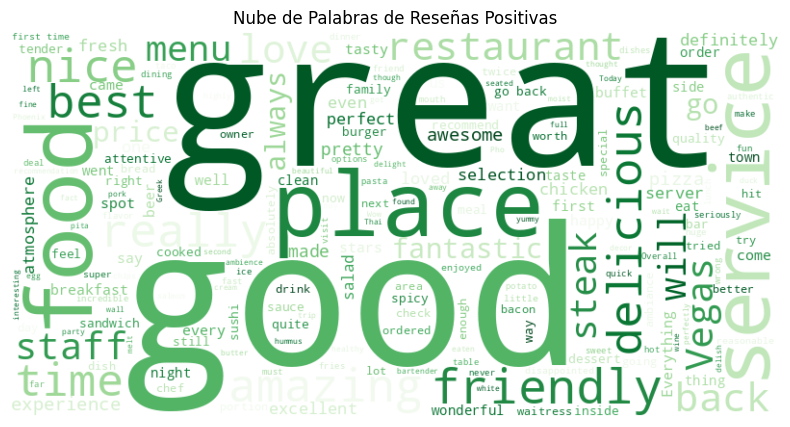

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generar nube de palabras para reseñas negativas
text_negativas = ' '.join(negativas['Review'].astype(str))
wordcloud_negativas = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_negativas)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negativas, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Reseñas Negativas')
plt.show()

# Generar nube de palabras para reseñas positivas
text_positivas = ' '.join(positivas['Review'].astype(str))
wordcloud_positivas = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(text_positivas)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positivas, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Reseñas Positivas')
plt.show()

## Insights y Conclusiones del Análisis de Satisfacción del Cliente

Basado en el análisis exploratorio de las reseñas de restaurantes, podemos extraer las siguientes conclusiones:

*   **¿Cuál es el % de clientes insatisfechos?**
    Aproximadamente el **50%** de los clientes expresaron insatisfacción. De un total de 1000 reseñas, 500 fueron clasificadas como negativas (`Liked = 0`), lo que indica un balance equitativo entre opiniones positivas y negativas en el dataset.

*   **¿Qué 3 palabras dominan las reseñas negativas?**
    Tras filtrar las `stopwords` básicas, las tres palabras que dominan las reseñas negativas son:
    1.  **'food'** (66 apariciones)
    2.  **'place'** (49 apariciones)
    3.  **'back'** (38 apariciones)
    Estas palabras sugieren que las quejas frecuentemente se relacionan con la calidad de la comida, el ambiente o la experiencia general del lugar, y la renuencia de los clientes a regresar.

*   **¿Qué acción de mejora proponés como profesional de Calidad?**
    Considerando que `food` y `place` son las palabras más recurrentes en las críticas negativas, y `service` también aparece con frecuencia, la acción de mejora debería enfocarse en estos puntos clave. Propongo la implementación de un programa de mejora continua utilizando el **Ciclo PDCA (Planificar, Hacer, Verificar, Actuar)**:

    **1. PLANIFICAR (Plan):**
    *   **Definición del Problema:** Alta tasa de insatisfacción (50%) centrada en la calidad de la comida, el ambiente del local y el servicio, llevando a que los clientes no deseen regresar.
    *   **Objetivo:** Reducir la tasa de reseñas negativas en un X% (ej. 15-20%) en los próximos Y meses, mejorando la percepción de la comida, el ambiente y el servicio.
    *   **Análisis de Causa Raíz:** Investigar en profundidad las razones detrás de las menciones de 'food', 'place' y 'service' en reseñas negativas. Esto podría incluir encuestas más detalladas, análisis de comentarios específicos y observación en sitio.
    *   **Plan de Acción:**
        *   Desarrollar nuevos estándares de calidad para la preparación y presentación de platos.
        *   Identificar áreas de mejora en la infraestructura y diseño del local.
        *   Crear un programa de capacitación intensiva en atención al cliente y resolución de conflictos para el personal.

    **2. HACER (Do):**
    *   **Implementación de Acciones:** Poner en práctica las iniciativas planificadas:
        *   Implementar los nuevos estándares de cocina y realizar pruebas de menú.
        *   Ejecutar mejoras estéticas y funcionales en áreas clave del restaurante (ej. limpieza, iluminación, mobiliario).
        *   Llevar a cabo las sesiones de capacitación para todo el personal de contacto con el cliente.
        *   Establecer un sistema de retroalimentación interna para el personal sobre las nuevas prácticas.

    **3. VERIFICAR (Check):**
    *   **Monitoreo y Evaluación:** Medir la efectividad de las acciones implementadas:
        *   Analizar la evolución del sentimiento de las reseñas (ej. disminución de menciones negativas de 'food', 'place', 'service').
        *   Realizar encuestas de satisfacción post-visita a los clientes para recoger feedback directo sobre las mejoras.
        *   Evaluar el desempeño del personal post-capacitación mediante métricas de servicio o 'cliente misterioso'.
        *   Comparar la tasa de reseñas negativas antes y después de la implementación de las mejoras.

    **4. ACTUAR (Act):**
    *   **Estandarización/Ajuste:** Basado en los resultados de la verificación:
        *   Si las mejoras son efectivas, estandarizar los nuevos procesos y procedimientos para asegurar su sostenibilidad.
        *   Si los resultados no cumplen los objetivos, analizar las desviaciones, ajustar el plan de acción y reiniciar el ciclo PDCA (Planificar, Hacer, Verificar, Actuar) con nuevas estrategias.